In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import os
import pandas as pd
import sys
from pathlib import Path

# Add scripts to path
sys.path.insert(0, '/home/student/s/ssahu/share/aigm-classifier/scripts')

data_dir = "/home/student/s/ssahu/share/aigm-classifier/data"
cached_spec_dir = f"{data_dir}/cached_spectrograms"

# Load spectrograms from directory structure (label subdirectories)
spec_data = []
for label_dir in os.listdir(cached_spec_dir):
    label_path = os.path.join(cached_spec_dir, label_dir)
    if os.path.isdir(label_path):
        label = int(label_dir)
        for spec_file in sorted(os.listdir(label_path)):
            if spec_file.endswith('.npy'):
                spec_path = os.path.join(label_path, spec_file)
                spec_data.append({
                    'label': label,
                    'spectrogram_path': spec_path,
                    'filename': spec_file
                })

df = pd.DataFrame(spec_data).sort_values('spectrogram_path').reset_index(drop=True)

if len(df) > 0:
    print(f"✅ Loaded {len(df)} cached spectrograms")
    print(f"\nLabel distribution:")
    print(df['label'].value_counts().sort_index())
    print(f"\nFirst 5 samples:")
    print(df.head())
else:
    print(f"❌ No spectrograms found in {cached_spec_dir}")

✅ Loaded 5632 cached spectrograms

Label distribution:
label
0    2838
1    2794
Name: count, dtype: int64

First 5 samples:
   label                                   spectrogram_path    filename
0      0  /home/student/s/ssahu/share/aigm-classifier/da...  000000.npy
1      0  /home/student/s/ssahu/share/aigm-classifier/da...  000001.npy
2      0  /home/student/s/ssahu/share/aigm-classifier/da...  000002.npy
3      0  /home/student/s/ssahu/share/aigm-classifier/da...  000003.npy
4      0  /home/student/s/ssahu/share/aigm-classifier/da...  000007.npy


📊 Sample 0:
   Label: 0
   Shape: (1, 128, 216)
   Path: /home/student/s/ssahu/share/aigm-classifier/data/cached_spectrograms/0/000000.npy
   Min: -2.81, Max: 3.14


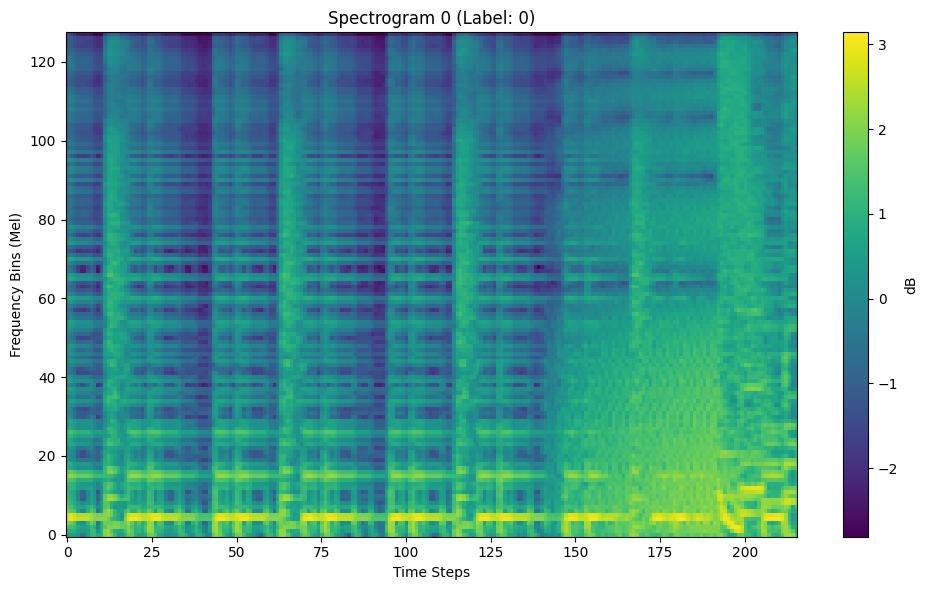

In [4]:
def load_spectrogram(idx):
    """Load a single spectrogram by index from the dataframe."""
    if idx >= len(df):
        print(f"❌ Index {idx} out of range (max: {len(df)-1})")
        return None
    
    row = df.iloc[idx]
    spec_path = row['spectrogram_path']
    label = row['label']
    
    if not os.path.exists(spec_path):
        print(f"❌ File not found: {spec_path}")
        return None
    
    spec = np.load(spec_path)
    return spec, label, spec_path

# Choose an index to view (e.g., the first one)
sample_idx = 0

spec, label, path = load_spectrogram(sample_idx)

if spec is not None:
    print(f"📊 Sample {sample_idx}:")
    print(f"   Label: {label}")
    print(f"   Shape: {spec.shape}")
    print(f"   Path: {path}")
    print(f"   Min: {spec.min():.2f}, Max: {spec.max():.2f}")
    
    plt.figure(figsize=(10, 6))
    plt.imshow(spec[0], cmap='viridis', origin='lower', aspect='auto')
    plt.title(f"Spectrogram {sample_idx} (Label: {label})")
    plt.colorbar(label='dB')
    plt.xlabel("Time Steps")
    plt.ylabel("Frequency Bins (Mel)")
    plt.tight_layout()
    plt.show()

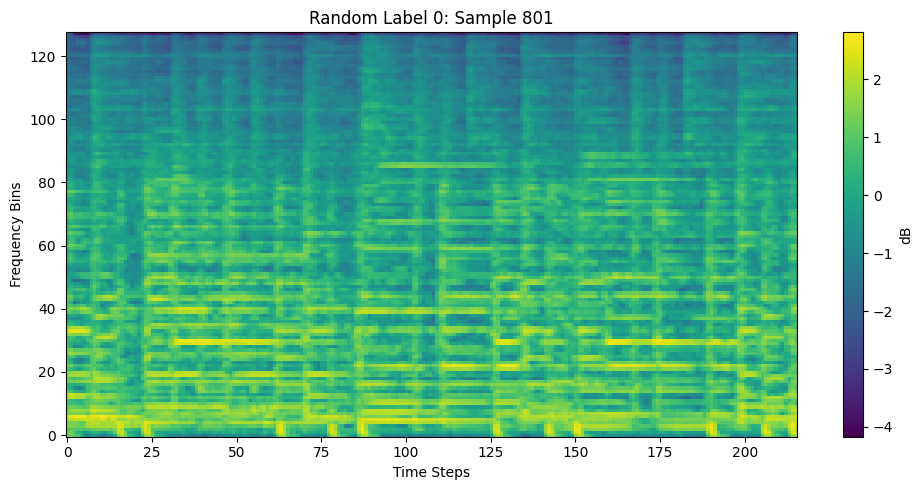

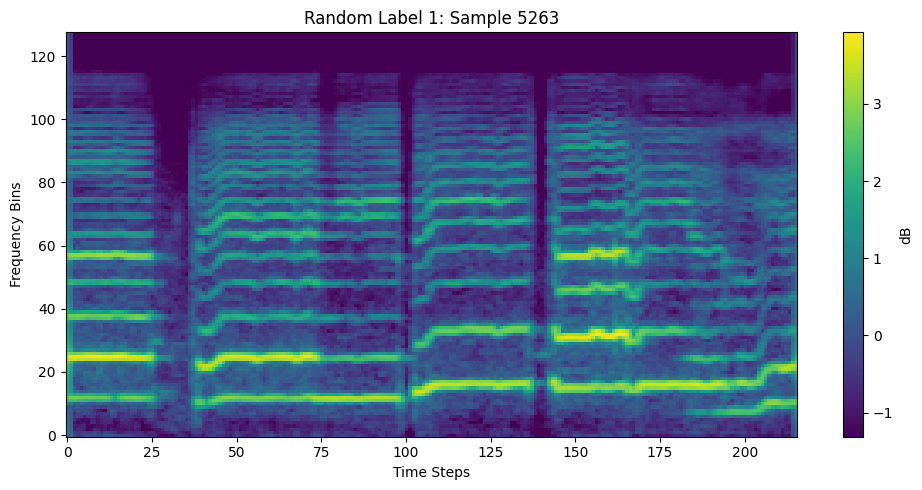

In [5]:
# Browse random samples
import random

# Pick random samples from each label
for label in [0, 1]:
    label_samples = df[df['label'] == label].sample(1)
    idx = label_samples.index[0]
    spec, lbl, path = load_spectrogram(idx)
    
    if spec is not None:
        plt.figure(figsize=(10, 5))
        plt.imshow(spec[0], cmap='viridis', origin='lower', aspect='auto')
        plt.title(f"Random Label {label}: Sample {idx}")
        plt.colorbar(label='dB')
        plt.xlabel("Time Steps")
        plt.ylabel("Frequency Bins")
        plt.tight_layout()
        plt.show()